In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("amazon_baby.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183531 entries, 0 to 183530
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   name    183213 non-null  object
 1   review  182702 non-null  object
 2   rating  183531 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.2+ MB


In [3]:
# Group by 'name' and count occurrences, then sort in descending order.
name_counts = df.groupby('name').size().reset_index(name='count').sort_values('count', ascending=False)
name_counts

,name,count
30996,Vulli Sophie the Giraffe Teether,785
26131,"Simple Wishes Hands-Free Breastpump Bra, Pink,...",562
14335,Infant Optics DXR-5 2.4 GHz Digital Video Baby...,561
2295,Baby Einstein Take Along Tunes,547
7163,"Cloud b Twilight Constellation Night Light, Tu...",520
...,...,...
6688,Chicco Ct 0.5 Twin Stroller - Alaska Pattern: ...,1
19309,Moby Baby Bonnet Sun Hat - Sienna,1
19310,Moby D Wrap Baby Carrier - Sage w/ Black,1
6682,Chicco Cortina Together Double Stroller - Roma...,1


### Examine the reivews for the most-reviewed product

In [4]:
giraffe_reviews = df[df['name']=='Vulli Sophie the Giraffe Teether']
giraffe_reviews

,name,review,rating
34313,Vulli Sophie the Giraffe Teether,He likes chewing on all the parts especially t...,5
34314,Vulli Sophie the Giraffe Teether,My son loves this toy and fits great in the di...,5
34315,Vulli Sophie the Giraffe Teether,There really should be a large warning on the ...,1
34316,Vulli Sophie the Giraffe Teether,All the moms in my moms' group got Sophie for ...,5
34317,Vulli Sophie the Giraffe Teether,I was a little skeptical on whether Sophie was...,5
...,...,...,...
159649,Vulli Sophie the Giraffe Teether,My baby loves her Sophie Chew Toy. She can che...,5
159650,Vulli Sophie the Giraffe Teether,Sophie the Giraffe was a big hit at the baby s...,5
159651,Vulli Sophie the Giraffe Teether,quick shipping and perfect product. I would pu...,5
159652,Vulli Sophie the Giraffe Teether,My baby who is currently teething love his Sop...,5


In [5]:
len(giraffe_reviews)

785

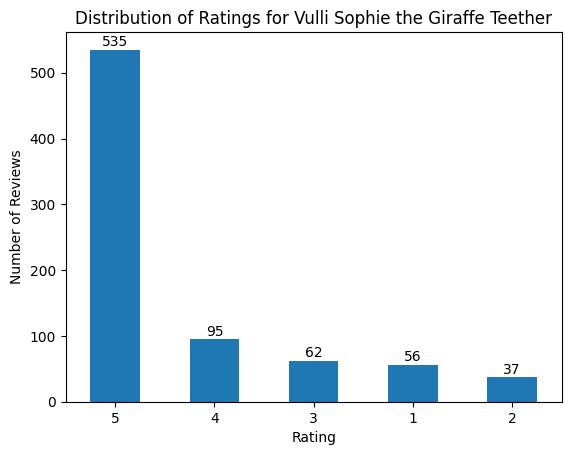

In [6]:
#  bar chart giraffe_reviews['rating']

giraffe_reviews['rating'].value_counts().plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Ratings for Vulli Sophie the Giraffe Teether')
plt.xticks(rotation=0, fontsize=10)  # Rotate x-axis labels for better readability
# Add numbers on top of each bar
for i, v in enumerate(giraffe_reviews['rating'].value_counts()):
    plt.text(i, v + 1, str(v), ha='center', va='bottom') # Adjust vertical alignment and add padding

plt.show()

### Building a sentiment classifier

#### - Build word count vectors

In [7]:
from collections import Counter
import re #a powerful tool for searching, matching, and manipulating text using patterns.
# Define a function to count words
def count_words(text):
    if pd.isnull(text):
        return {}
    words = re.findall(r'\b\w+\b', text.lower())
    return dict(Counter(words))

# Apply it to the 'review' column
df['word_count'] = df['review'].apply(count_words)
df['word_count']

0         {'these': 1, 'flannel': 1, 'wipes': 4, 'are': ...
1         {'it': 3, 'came': 1, 'early': 1, 'and': 3, 'wa...
2         {'very': 1, 'soft': 1, 'and': 2, 'comfortable'...
3         {'this': 4, 'is': 4, 'a': 2, 'product': 2, 'we...
4         {'all': 2, 'of': 1, 'my': 1, 'kids': 2, 'have'...
                                ...                        
183526    {'such': 1, 'a': 1, 'great': 2, 'idea': 1, 've...
183527    {'this': 1, 'product': 2, 'rocks': 1, 'it': 2,...
183528    {'this': 2, 'item': 1, 'looks': 1, 'great': 2,...
183529    {'i': 9, 'am': 2, 'extremely': 1, 'happy': 1, ...
183530    {'i': 2, 'love': 1, 'this': 1, 'product': 1, '...
Name: word_count, Length: 183531, dtype: object

**Define what is positive and negative sentiment**


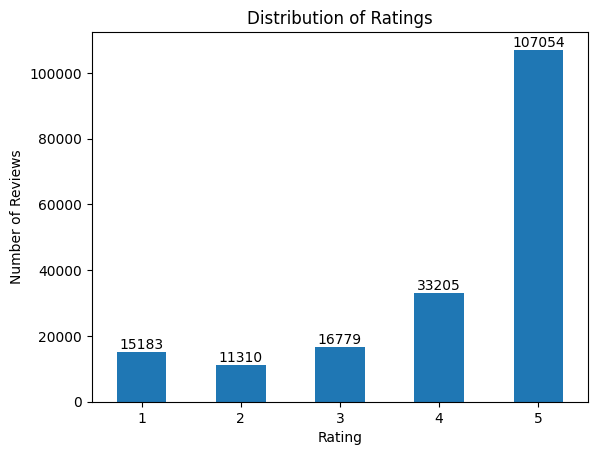

In [8]:
# prompt: bar plot df['ratings']

df['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Ratings')
plt.xticks(rotation=0)

# Add numbers on top of each bar
for i, v in enumerate(df['rating'].value_counts().sort_index()):
    plt.text(i, v + 1, str(v), ha='center', va='bottom')

plt.show()

In [9]:
#ignore all 3*  reviews
df = df[df['rating']!=3]

In [10]:
#positive sentiment = 4-star or 5-star reviews
df['sentiment'] = df['rating'] >= 4

**Train our sentiment classifier**

In [11]:
# Train our sentiment classifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Split the data
train_data, test_data = train_test_split(df, test_size=0.2, random_state=0)

# 2. Prepare features and target
X_train = train_data['word_count']
X_test = test_data['word_count']
y_train = train_data['sentiment']
y_test = test_data['sentiment']

In [12]:
# 3. Vectorize the word counts
from sklearn.feature_extraction import DictVectorizer
vec = DictVectorizer()
X_train = vec.fit_transform(X_train)
X_test = vec.transform(X_test)

# 4. Train logistic regression
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# 5. Evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9287877424964769


/Users/jipingwang/.pyenv/versions/3.8.20/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# prompt: model predict(df, output_type = 'probability')  and add it to df

def predict_with_probability(model, df, vec, output_type='probability'):
    """
    Predicts sentiment and adds the prediction to the dataframe.

    Args:
        model: The trained logistic regression model.
        df: The DataFrame containing the data to predict on.
        vec: The DictVectorizer used to transform the word counts.
        output_type: 'probability' or 'label', decides output format of the model.

    Returns:
        The DataFrame with the added 'predicted_sentiment' column.
    """

    # Transform the word counts using the same vectorizer used for training
    X = vec.transform(df['word_count'])

    if output_type == 'probability':
      # Get predicted probabilities for the positive class
      predicted_probabilities = model.predict_proba(X)[:, 1]
      df['predicted_sentiment'] = predicted_probabilities
    elif output_type == 'label':
      # Get predicted labels (0 or 1)
      predicted_labels = model.predict(X)
      df['predicted_sentiment'] = predicted_labels
    else:
        raise ValueError("output_type must be 'probability' or 'label'")

    return df

# Example usage (assuming 'model' and 'vec' are defined as in the previous code):
# Make sure df['word_count'] is available for this to work.
df = predict_with_probability(model, df, vec, output_type='probability')
#To get labels instead of probabilities:
#df = predict_with_probability(model, df, vec, output_type='label')
print(df.head())


                                                name  \
1                              Planetwise Wipe Pouch   
2                Annas Dream Full Quilt with 2 Shams   
3  Stop Pacifier Sucking without tears with Thumb...   
4  Stop Pacifier Sucking without tears with Thumb...   
5  Stop Pacifier Sucking without tears with Thumb...   

                                              review  rating  \
1  it came early and was not disappointed. i love...       5   
2  Very soft and comfortable and warmer than it l...       5   
3  This is a product well worth the purchase.  I ...       5   
4  All of my kids have cried non-stop when I trie...       5   
5  When the Binky Fairy came to our house, we did...       5   

                                          word_count  sentiment  \
1  {'it': 3, 'came': 1, 'early': 1, 'and': 3, 'wa...       True   
2  {'very': 1, 'soft': 1, 'and': 2, 'comfortable'...       True   
3  {'this': 4, 'is': 4, 'a': 2, 'product': 2, 'we...       True   
4  {'all':

In [14]:
giraffe_reviews = df[df['name']== 'Vulli Sophie the Giraffe Teether']
giraffe_reviews

,name,review,rating,word_count,sentiment,predicted_sentiment
34313,Vulli Sophie the Giraffe Teether,He likes chewing on all the parts especially t...,5,"{'he': 2, 'likes': 1, 'chewing': 1, 'on': 1, '...",True,0.998581
34314,Vulli Sophie the Giraffe Teether,My son loves this toy and fits great in the di...,5,"{'my': 1, 'son': 1, 'loves': 1, 'this': 1, 'to...",True,0.999402
34315,Vulli Sophie the Giraffe Teether,There really should be a large warning on the ...,1,"{'there': 2, 'really': 1, 'should': 1, 'be': 1...",False,0.180777
34316,Vulli Sophie the Giraffe Teether,All the moms in my moms' group got Sophie for ...,5,"{'all': 1, 'the': 2, 'moms': 2, 'in': 1, 'my':...",True,0.971800
34317,Vulli Sophie the Giraffe Teether,I was a little skeptical on whether Sophie was...,5,"{'i': 4, 'was': 2, 'a': 1, 'little': 1, 'skept...",True,0.809818
...,...,...,...,...,...,...
159649,Vulli Sophie the Giraffe Teether,My baby loves her Sophie Chew Toy. She can che...,5,"{'my': 2, 'baby': 1, 'loves': 1, 'her': 1, 'so...",True,0.994886
159650,Vulli Sophie the Giraffe Teether,Sophie the Giraffe was a big hit at the baby s...,5,"{'sophie': 2, 'the': 2, 'giraffe': 1, 'was': 1...",True,0.895948
159651,Vulli Sophie the Giraffe Teether,quick shipping and perfect product. I would pu...,5,"{'quick': 1, 'shipping': 1, 'and': 1, 'perfect...",True,0.999655
159652,Vulli Sophie the Giraffe Teether,My baby who is currently teething love his Sop...,5,"{'my': 1, 'baby': 1, 'who': 1, 'is': 1, 'curre...",True,0.995665


**Sort the Giraffe reviews according to predicted sentiment**

In [15]:
# prompt: Sort the Giraffe reviews according to predicted sentiment

giraffe_reviews_sorted = giraffe_reviews.sort_values('predicted_sentiment', ascending=False)
giraffe_reviews_sorted


,name,review,rating,word_count,sentiment,predicted_sentiment
34892,Vulli Sophie the Giraffe Teether,"Sophie, oh Sophie, your time has come. My gran...",5,"{'sophie': 21, 'oh': 1, 'your': 1, 'time': 2, ...",True,1.000000e+00
34434,Vulli Sophie the Giraffe Teether,My Mom-in-Law bought Sophie for my son when he...,5,"{'my': 7, 'mom': 1, 'in': 5, 'law': 1, 'bought...",True,1.000000e+00
34515,Vulli Sophie the Giraffe Teether,"As every mom knows, you always want to give yo...",5,"{'as': 2, 'every': 1, 'mom': 1, 'knows': 1, 'y...",True,1.000000e+00
34410,Vulli Sophie the Giraffe Teether,Our son really likes Sopie...the problem is th...,5,"{'our': 3, 'son': 3, 'really': 1, 'likes': 1, ...",True,1.000000e+00
34975,Vulli Sophie the Giraffe Teether,My 8 week old LOVES Sophie. The rubber feels s...,5,"{'my': 3, '8': 1, 'week': 1, 'old': 1, 'loves'...",True,1.000000e+00
...,...,...,...,...,...,...
35018,Vulli Sophie the Giraffe Teether,"My son (now 2.5) LOVED his Sophie, and I bough...",1,"{'my': 4, 'son': 1, 'now': 2, '2': 1, '5': 1, ...",False,1.001822e-04
34732,Vulli Sophie the Giraffe Teether,Received the product and smells like cheap rub...,1,"{'received': 1, 'the': 1, 'product': 1, 'and':...",False,8.088336e-05
34556,Vulli Sophie the Giraffe Teether,"Alright, first off didn't realize this was a s...",2,"{'alright': 1, 'first': 1, 'off': 1, 'didn': 1...",False,7.615537e-05
34748,Vulli Sophie the Giraffe Teether,"My daughter loves Sophie, but we received her ...",2,"{'my': 1, 'daughter': 1, 'loves': 1, 'sophie':...",False,4.586544e-05


In [16]:
# Display the most positive review for the giraffe toy.
print(giraffe_reviews_sorted.iloc[0]['review'])


Sophie, oh Sophie, your time has come. My granddaughter, Violet is 5 months old and starting to teeth. What joy little Sophie brings to Violet. Sophie is made of a very pliable rubber that is sturdy but not tough. It is quite easy for Violet to twist Sophie into unheard of positions to get Sophie into her mouth. The little nose and hooves fit perfectly into small mouths, and the drooling has purpose. The paint on Sophie is food quality.Sophie was born in 1961 in France. The maker had wondered why there was nothing available for babies and made Sophie from the finest rubber, phthalate-free on St Sophie's Day, thus the name was born. Since that time millions of Sophie's populate the world. She is soft and for babies little hands easy to grasp. Violet especially loves the bumpy head and horns of Sophie. Sophie has a long neck that easy to grasp and twist. She has lovely, sizable spots that attract Violet's attention. Sophie has happy little squeaks that bring squeals of delight from Viole

In [17]:
# prompt: Most negative reivews

# Display the most negative review for the giraffe toy.
print(giraffe_reviews_sorted.iloc[-1]['review'])
print(giraffe_reviews_sorted.iloc[-2]['review'])

I wanted to love this product and was excited to buy it when I became pregnant but am now hesitant to let my baby use it after reading about the recall in Europe. Apparently, as I understand it, their toxin standards of measurement are lower than ours so they have not been recalled here (apparently we are OK with low levels of nitrates in the toys our children put in their mouths, but Europeans are not...hmmm)...Be that as it may, toxins registering even CLOSE to a dangerous level made me nervous about using. After digging around online I did discover that the company claims to have changed the product after a certain date and lists manufacturing codes so you can check yours (those listed were made after a certain date and are said to be safer). Sadly mine was not made after the &#34;improved&#34; date but I could not return it because there was no formal recall in our country. I considered returning it and hunting for one with an approved manufacturing date but man that was just too m

In [18]:
selected_words = ['awesome', 'great', 'fantastic', 'amazing', 'love', 'horrible', 'bad', 'terrible', 'awful', 'wow', 'hate']

In [19]:
#Q1: Out of the 11 words in selected_words, which one is most used in the reviews in the dataset?
from collections import Counter

# Create a Counter object to store word frequencies
word_counts = Counter()

# Iterate through the reviews and update the word counts
for review in df['review']:
    if isinstance(review, str):  # Check if the review is a string
        words = re.findall(r'\b\w+\b', review.lower())
        word_counts.update(words)

# Create a dictionary to store frequencies of selected words
selected_word_counts = {}
for word in selected_words:
    selected_word_counts[word] = word_counts[word]

# Sort the selected words by frequency in descending order
sorted_word_counts = dict(sorted(selected_word_counts.items(), key=lambda item: item[1], reverse=True))


# Print the sorted list with frequencies
for word, count in sorted_word_counts.items():
    print(f"{word}: {count}")

# Find the most used word
most_used_word = max(sorted_word_counts, key=sorted_word_counts.get)
print(f"\nThe most used word in the selected words is: {most_used_word}")

great: 55791
love: 41994
bad: 4183
awesome: 3892
amazing: 2628
fantastic: 1664
terrible: 1146
horrible: 1110
hate: 1107
awful: 687
wow: 425

The most used word in the selected words is: great


In [20]:
#Q2: Out of the 11 words in selected_words, which one is least used in the reviews in the dataset?  
least_used_word = min(word_counts, key=word_counts.get)
print(f"The least used word out of the selected words is: {least_used_word}")

The least used word out of the selected words is: keps


In [21]:
# Q3/Q4: Out of the 11 words in selected_words, which one got the most positive/negative weight in the selected_words_model? 
# Get the coefficients from the trained logistic regression model.
coefficients = model.coef_[0]

# Create a dictionary to store the coefficients for selected words.
selected_words_coef = {}

# Find the indices of the selected words in the vocabulary.
for word in selected_words:
    try:
      word_index = vec.vocabulary_[word]
      selected_words_coef[word] = coefficients[word_index]
    except KeyError:
      # Handle cases where a word from selected_words is not in the vocabulary
      print(f"Warning: '{word}' not found in the vocabulary.")
      selected_words_coef[word] = 0 # Or assign a default value

# Find the word with the largest coefficient (most positive weight).
most_positive_word = max(selected_words_coef, key=selected_words_coef.get)

# Print the list of coefficients for selected words
print("Coefficients for selected words:")
for word, coef in selected_words_coef.items():
  print(f"{word}: {coef}")

print(f"\nThe word with the most positive weight is: {most_positive_word} with a coefficient of {selected_words_coef[most_positive_word]}")


Coefficients for selected words:
awesome: 1.83195595419147
great: 1.2464284373487489
fantastic: 1.571494420275885
amazing: 1.6338910466265928
love: 1.5479830009898439
horrible: -1.7738318236511912
bad: -0.42659711609061185
terrible: -1.8882100262913324
awful: -1.3241616390731297
wow: 0.19308115284296284
hate: -1.382837493432153

The word with the most positive weight is: awesome with a coefficient of 1.83195595419147


In [22]:
#  Create a new sentiment analysis model using only the selected_words as features:  

selected_words_df = pd.DataFrame(0, index=df.index, columns=selected_words)

for word in selected_words:
    # Fill NaN values with an empty string before applying string methods
    selected_words_df[word] = df['review'].fillna('').str.lower().str.contains(word).astype(int)

# Combine the new features with the sentiment labels.
selected_words_df['sentiment'] = df['sentiment']

# Split the data
train_data, test_data = train_test_split(selected_words_df, test_size=0.2, random_state=0)

X_train = train_data.drop('sentiment', axis=1)
X_test = test_data.drop('sentiment', axis=1)
y_train = train_data['sentiment']
y_test = test_data['sentiment']

# Train logistic regression
selected_words_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# Evaluate
selected_words_predictions = selected_words_model.predict(X_test)
selected_words_accuracy = accuracy_score(y_test, selected_words_predictions)
print(f"Accuracy of the model using only selected words: {selected_words_accuracy}")

Accuracy of the model using only selected words: 0.8453119846481365


In [23]:
# Use .apply() to build a new feature with the counts for each of the selected_words

for word in selected_words:
    df[word] = df['review'].apply(lambda x: word in str(x).lower() if isinstance(x, str) else False)
    
# Calculate the sum of the selected words for each review
df['selected_words_count'] = df[selected_words].sum(axis=1)
print(df.head())

                                                name  \
1                              Planetwise Wipe Pouch   
2                Annas Dream Full Quilt with 2 Shams   
3  Stop Pacifier Sucking without tears with Thumb...   
4  Stop Pacifier Sucking without tears with Thumb...   
5  Stop Pacifier Sucking without tears with Thumb...   

                                              review  rating  \
1  it came early and was not disappointed. i love...       5   
2  Very soft and comfortable and warmer than it l...       5   
3  This is a product well worth the purchase.  I ...       5   
4  All of my kids have cried non-stop when I trie...       5   
5  When the Binky Fairy came to our house, we did...       5   

                                          word_count  sentiment  \
1  {'it': 3, 'came': 1, 'early': 1, 'and': 3, 'wa...       True   
2  {'very': 1, 'soft': 1, 'and': 2, 'comfortable'...       True   
3  {'this': 4, 'is': 4, 'a': 2, 'product': 2, 'we...       True   
4  {'all':

In [24]:
df[selected_words]

,awesome,great,fantastic,amazing,love,horrible,bad,terrible,awful,wow,hate
1,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False
4,False,True,False,False,True,False,False,False,False,False,False
5,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
183526,False,True,False,False,False,False,False,False,False,False,False
183527,False,True,False,False,False,False,False,False,False,False,False
183528,False,True,False,False,False,False,False,False,False,False,False
183529,False,False,False,False,False,False,False,False,False,False,False


In [25]:

from sklearn.model_selection import train_test_split # import train_test_split

# Split the data into training and testing sets
#train_data, test_data = df.random_split(.8, seed=0) # remove this line
train_data, test_data = train_test_split(df, test_size=0.2, random_state=0) #use train_test_split instead

# Define features (selected words)
features = selected_words

# Create a new logistic regression model
selected_words_model = LogisticRegression()

# Train the model on the selected word features
selected_words_model.fit(train_data[features], train_data['sentiment'])

# Predict sentiment on the test data
selected_words_predictions = selected_words_model.predict(test_data[features])

# Evaluate the model
selected_words_accuracy = accuracy_score(test_data['sentiment'], selected_words_predictions)
print("Accuracy of selected_words_model:", selected_words_accuracy)

Accuracy of selected_words_model: 0.8453119846481365


In [26]:
# Accuracy of the original model (using word counts)
print("Accuracy of original model (word counts):", accuracy)

# Accuracy of the model using selected words
print("Accuracy of selected words model:", selected_words_accuracy)

Accuracy of original model (word counts): 0.9287877424964769
Accuracy of selected words model: 0.8453119846481365


In [27]:
# Get the coefficients of the selected_words_model
coefficients = selected_words_model.coef_[0]

# Create a list of (word, coefficient) tuples
word_coefficients = list(zip(selected_words, coefficients))

# Sort the list by coefficient in descending order
sorted_word_coefficients = sorted(word_coefficients, key=lambda x: x[1], reverse=True)

# Print the sorted list
for word, coefficient in sorted_word_coefficients:
    print(f"Word: {word}, Coefficient: {coefficient}")

Word: love, Coefficient: 1.577535847538161
Word: awesome, Coefficient: 1.2174800454981205
Word: amazing, Coefficient: 1.1342923096488886
Word: great, Coefficient: 1.0609273939840211
Word: fantastic, Coefficient: 0.9833508723082681
Word: wow, Coefficient: -0.12931244212815168
Word: hate, Coefficient: -0.8355501675220234
Word: bad, Coefficient: -1.114332706243781
Word: awful, Coefficient: -2.043838436966485
Word: terrible, Coefficient: -2.3015900916193126
Word: horrible, Coefficient: -2.3295395650531585
